In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(/content/seasonal_agriculture_performance_dataset.csv)

SyntaxError: invalid syntax (1524444664.py, line 1)

In [3]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [4]:
df.dropna(inplace=True)

In [5]:
print("Cleaned Dataset Overview:")
display(df.head())
print("\nDataset Info:")
df.info()

Cleaned Dataset Overview:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3880 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        3880 non-null   object 
 1   State                          3880 non-null   object 
 2   District                       3880 non-null   object 
 3   Crop                           3880 non-null   object 
 4   Season                         3880 non-null   object 
 5   Farm_Area_Hectares             3880 non-null   float64
 6   Rainfall_mm                    3880 non-null   float64
 7   Avg_Temperature_C              3880 non-null   float64
 8   Humidity_pct                   3880 non-null   float64
 9   Sunlight_Hours_Day             3880 non-null   float64
 10  Soil_pH                        3880 non-null   float64
 11  Soil_Moisture_pct              3880 non-null   float64
 12  Nitrogen_kg_ha                 3880 no

In [6]:
seasonal_performance = df.groupby('Season')['Production_Tonnes'].mean()

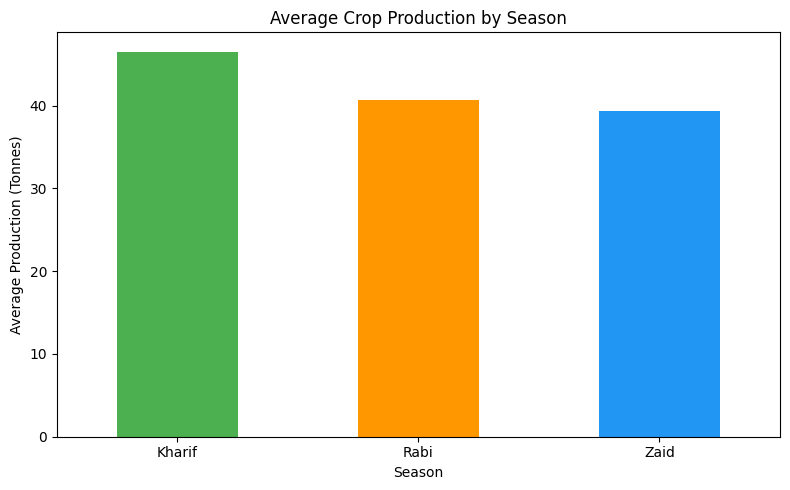

In [7]:
plt.figure(figsize=(8, 5))
seasonal_performance.plot(kind='bar', color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title('Average Crop Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
print("Maximum Production Recorded (Tonnes):", np.max(df['Production_Tonnes'].to_numpy()))
print("Average Overall Yield (Tonnes/Ha):", np.mean(df['Yield_Tonnes_Ha'].to_numpy()))

Maximum Production Recorded (Tonnes): 1424.4
Average Overall Yield (Tonnes/Ha): 5.2411520618556695


In [9]:
resource_usage = df.groupby('Season')[['Water_Used_m3', 'Fertilizer_kg_ha']].mean()

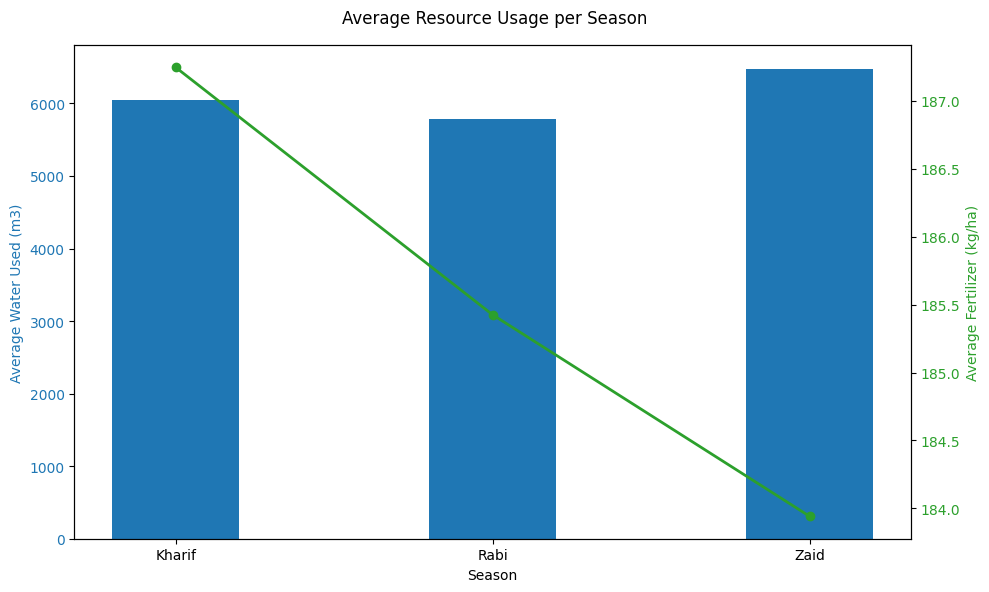

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Season')
ax1.set_ylabel('Average Water Used (m3)', color=color)
ax1.bar(resource_usage.index, resource_usage['Water_Used_m3'], width=0.4, label='Water Used', color=color, align='center')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Average Fertilizer (kg/ha)', color=color)
ax2.plot(resource_usage.index, resource_usage['Fertilizer_kg_ha'], color=color, marker='o', label='Fertilizer Used', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Average Resource Usage per Season')
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Agricultural Yield (Tonnes/Ha)')

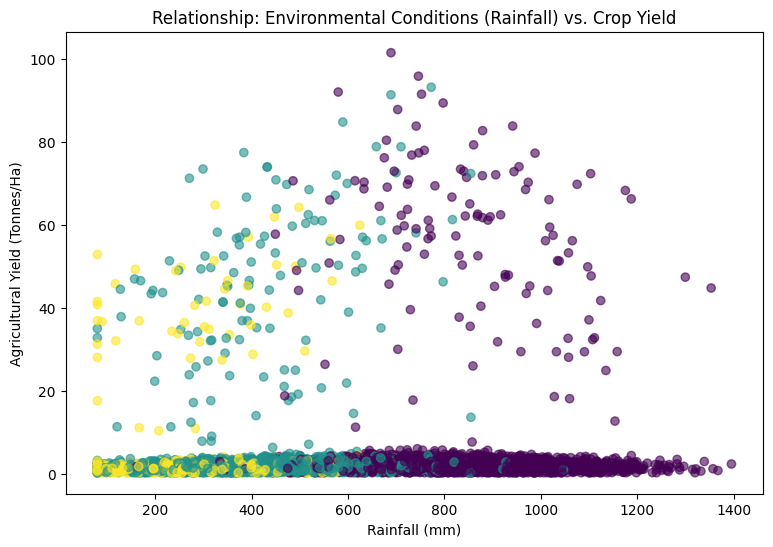

In [12]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], c=df['Season'].astype('category').cat.codes, cmap='viridis', alpha=0.6)
plt.title('Relationship: Environmental Conditions (Rainfall) vs. Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Agricultural Yield (Tonnes/Ha)')

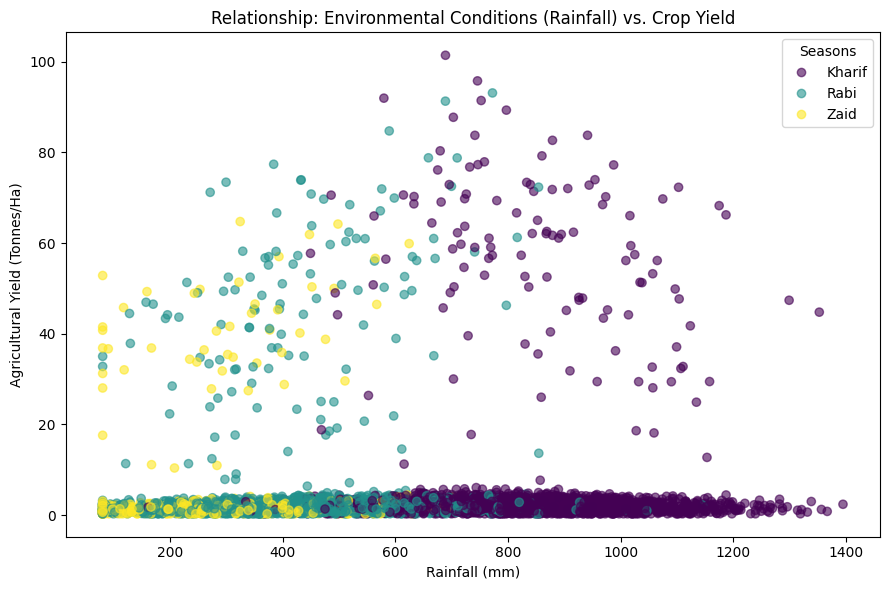

Correlation between Rainfall and Yield: 0.03


In [15]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'],
                      c=df['Season'].astype('category').cat.codes,
                      cmap='viridis', alpha=0.6)

plt.title('Relationship: Environmental Conditions (Rainfall) vs. Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Agricultural Yield (Tonnes/Ha)')

plt.legend(handles=scatter.legend_elements()[0],
           labels=df['Season'].astype('category').cat.categories.tolist(),
           title="Seasons")

plt.tight_layout()
plt.show()

correlation = np.corrcoef(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])[0, 1]
print(f"Correlation between Rainfall and Yield: {correlation:.2f}")

In [16]:
economic_outcomes = df.groupby('Season')['Revenue_INR'].sum()

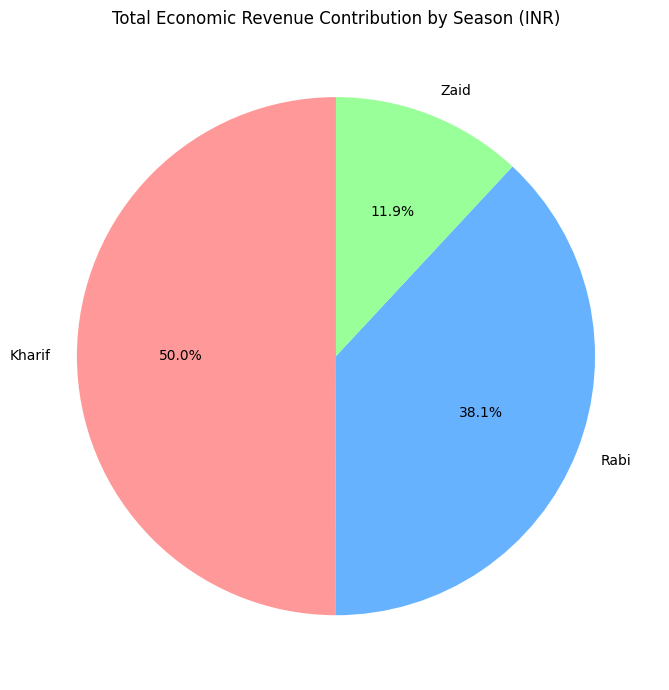

In [17]:
plt.figure(figsize=(7, 7))
plt.pie(economic_outcomes, labels=economic_outcomes.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b2ff','#99ff99'])
plt.title('Total Economic Revenue Contribution by Season (INR)')
plt.tight_layout()
plt.show()

In [18]:
print("Total Revenue by Season (INR):")
print(economic_outcomes)

Total Revenue by Season (INR):
Season
Kharif    1236169415
Rabi       942997743
Zaid       295058145
Name: Revenue_INR, dtype: int64
